# 01 — Sanity Check: MONAI Pipeline

**Sprint 2 — Checkpoint de verificación.**

Este notebook valida que el pipeline de datos MONAI produce tensores
con la forma correcta `(B, 1, 96, 96, 96)` y que las imágenes
se ven razonables tras el preprocesamiento.

**Criterios de éxito:**
- `batch['image'].shape` == `(4, 1, 96, 96, 96)`
- `batch['label'].shape` == `(4,)`
- Corte central muestra cerebro en gris, centrado, sin cráneo
- Intensidades normalizadas en rango [0, 1]

In [2]:
import sys
from pathlib import Path

# Asegurar que el directorio raíz del proyecto está en sys.path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: d:\clase\tfg


## 1. Verificar shapes del DataLoader

In [3]:
from src.dataset import get_dataloader
from src.config import cfg

print(f"Configuración: IMAGE_SIZE={cfg.IMAGE_SIZE}, BATCH_SIZE={cfg.BATCH_SIZE}")
print(f"Cargando DataLoader del split 'train'...")

train_loader = get_dataloader("train", batch_size=4)
batch = next(iter(train_loader))

print(f"\n--- Shapes ---")
print(f"batch['image'].shape = {batch['image'].shape}")
print(f"batch['image'].dtype  = {batch['image'].dtype}")
print(f"batch['label'].shape = {batch['label'].shape}")
print(f"batch['label'].dtype  = {batch['label'].dtype}")
print(f"batch['label']        = {batch['label']}")

# Asserts del checkpoint
assert batch["image"].shape == (4, 1, 96, 96, 96), (
    f"Shape incorrecto: {batch['image'].shape}, esperado (4, 1, 96, 96, 96)"
)
assert batch["label"].shape == (4,), (
    f"Shape incorrecto: {batch['label'].shape}, esperado (4,)"
)

print("\n=== CHECKPOINT 2.1 PASSED ===")

Configuración: IMAGE_SIZE=(96, 96, 96), BATCH_SIZE=4
Cargando DataLoader del split 'train'...


monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.



--- Shapes ---
batch['image'].shape = torch.Size([4, 1, 96, 96, 96])
batch['image'].dtype  = torch.float32
batch['label'].shape = torch.Size([4])
batch['label'].dtype  = torch.int64
batch['label']        = tensor([2, 2, 1, 0])

=== CHECKPOINT 2.1 PASSED ===


## 2. Visualización: corte central (axial, coronal, sagital)

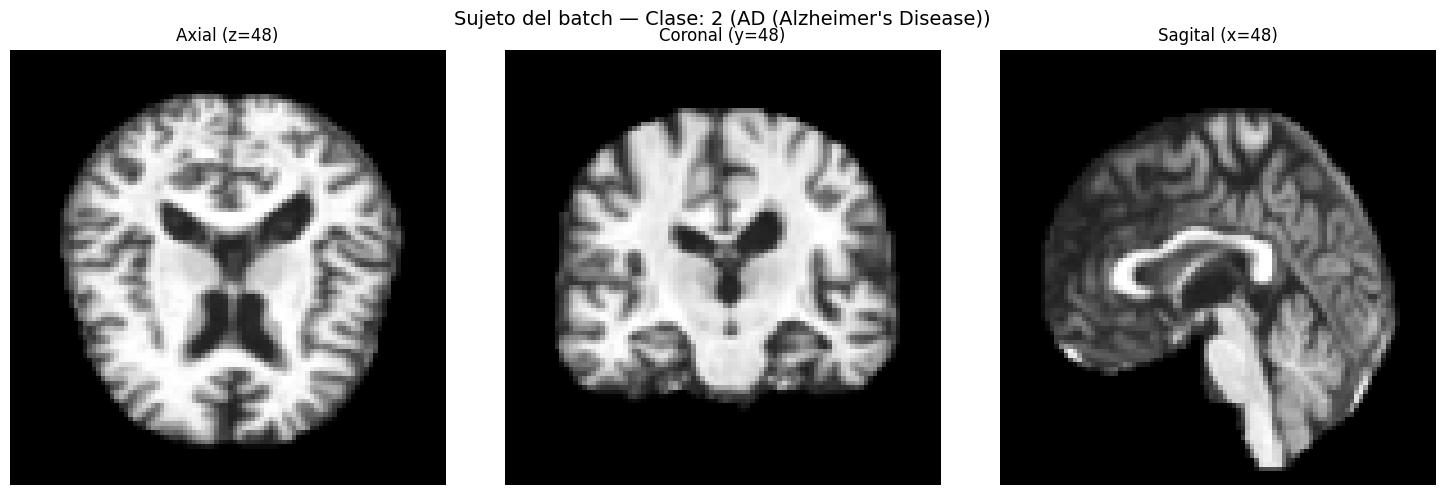


Si ves un cerebro en gris, centrado y sin cráneo -> OK
Si ves ruido estático o imagen negra -> revisa la normalización
Si el cerebro está rotado 90° -> revisa Orientationd


In [4]:
import matplotlib.pyplot as plt
import numpy as np

vol = batch["image"][0, 0].cpu().numpy()  # (96, 96, 96)
label = int(batch["label"][0])
label_name = cfg.CLASS_LABELS.get(label, "Unknown")

# En orientación RAS el tensor tiene ejes (X=Right-Left, Y=Anterior-Posterior, Z=Inferior-Superior)
cx, cy, cz = vol.shape[0] // 2, vol.shape[1] // 2, vol.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Sujeto del batch — Clase: {label} ({label_name})", fontsize=14)

# Axial: corta Z (sup-inf) → muestra plano X-Y, nariz hacia arriba
axes[0].imshow(np.rot90(vol[:, :, cz]), cmap="gray")
axes[0].set_title(f"Axial (z={cz})")
axes[0].axis("off")

# Coronal: corta Y (ant-post) → muestra plano X-Z, superior hacia arriba
axes[1].imshow(np.rot90(vol[:, cy, :]), cmap="gray")
axes[1].set_title(f"Coronal (y={cy})")
axes[1].axis("off")

# Sagital: corta X (right-left) → muestra plano Y-Z, superior hacia arriba
axes[2].imshow(np.rot90(vol[cx, :, :]), cmap="gray")
axes[2].set_title(f"Sagital (x={cx})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("\nSi ves un cerebro en gris, centrado y sin cráneo -> OK")
print("Si ves ruido estático o imagen negra -> revisa la normalización")
print("Si el cerebro está rotado 90° -> revisa Orientationd")

## 3. Estadísticas del tensor procesado

In [5]:
import numpy as np

print("--- Estadísticas del primer volumen del batch ---")
print(f"  min  = {vol.min():.4f}")
print(f"  max  = {vol.max():.4f}")
print(f"  mean = {vol.mean():.4f}")
print(f"  std  = {vol.std():.4f}")

# Verificar que la normalización produjo valores en [0, 1]
assert vol.min() >= 0.0, f"min={vol.min()}, debería ser >= 0"
assert vol.max() <= 1.0, f"max={vol.max()}, debería ser <= 1"

print(f"\n--- Distribución por split ---")
for split_name in ["train", "val", "test"]:
    from src.data_utils import load_split
    df = load_split(split_name)
    counts = df["label"].value_counts().sort_index()
    print(f"  {split_name:5s}: {len(df)} sujetos — {dict(counts)}")

print("\n=== CHECKPOINT 2.2 PASSED ===")

--- Estadísticas del primer volumen del batch ---
  min  = 0.0000
  max  = 1.0000
  mean = 0.1598
  std  = 0.2965

--- Distribución por split ---
  train: 164 sujetos — {0: np.int64(94), 1: np.int64(49), 2: np.int64(21)}
  val  : 35 sujetos — {0: np.int64(20), 1: np.int64(10), 2: np.int64(5)}
  test : 36 sujetos — {0: np.int64(21), 1: np.int64(11), 2: np.int64(4)}

=== CHECKPOINT 2.2 PASSED ===
